In [1]:
# Cell 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, f1_score, precision_score,
                             recall_score, average_precision_score)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import pickle
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


In [2]:
# Cell 2: Load Processed Data
print("=" * 50)
print("LOADING PROCESSED DATA")
print("=" * 50)

X_train = pd.read_csv('../../data/processed/X_train.csv')
y_train = pd.read_csv('../../data/processed/y_train.csv').squeeze()

X_val = pd.read_csv('../../data/processed/X_val.csv')
y_val = pd.read_csv('../../data/processed/y_val.csv').squeeze()

X_test = pd.read_csv('../../data/processed/X_test.csv')
y_test = pd.read_csv('../../data/processed/y_test.csv').squeeze()

print(f"X_train: {X_train.shape} | Fraud: {y_train.sum()}")
print(f"X_val:   {X_val.shape} | Fraud: {y_val.sum()}")
print(f"X_test:  {X_test.shape} | Fraud: {y_test.sum()}")

print("\n✅ All datasets loaded successfully!")

LOADING PROCESSED DATA
X_train: (396540, 37) | Fraud: 198270
X_val:   (42566, 37) | Fraud: 71
X_test:  (42559, 37) | Fraud: 71

✅ All datasets loaded successfully!


In [3]:
# Cell 3: Helper Function for Model Evaluation
def evaluate_model(model_name, y_true, y_pred, y_prob):
    print(f"\n{'='*50}")
    print(f"MODEL: {model_name}")
    print(f"{'='*50}")
    
    # Core metrics
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    roc_auc = roc_auc_score(y_true, y_prob)
    pr_auc = average_precision_score(y_true, y_prob)
    
    print(f"Precision:  {precision:.4f}  (of all flagged fraud, how many were real?)")
    print(f"Recall:     {recall:.4f}  (of all real fraud, how many did we catch?)")
    print(f"F1-Score:   {f1:.4f}  (balance of precision & recall)")
    print(f"ROC-AUC:    {roc_auc:.4f}  (overall discrimination ability)")
    print(f"PR-AUC:     {pr_auc:.4f}  (performance on imbalanced data)")
    
    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    print(f"\nConfusion Matrix:")
    print(f"  True Negative  (Legit correctly identified): {cm[0][0]:,}")
    print(f"  False Positive (Legit flagged as fraud):     {cm[0][1]:,}")
    print(f"  False Negative (Fraud missed):               {cm[1][0]:,}")
    print(f"  True Positive  (Fraud correctly caught):     {cm[1][1]:,}")
    
    return {
        'model': model_name,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'roc_auc': roc_auc,
        'pr_auc': pr_auc
    }

print("✅ Evaluation function ready!")

✅ Evaluation function ready!


In [4]:
# Cell 4: Logistic Regression - Baseline Model
print("=" * 50)
print("MODEL 1: LOGISTIC REGRESSION (Baseline)")
print("=" * 50)
print("Training... (this may take 1-2 minutes)")

lr_model = LogisticRegression(
    random_state=42,
    max_iter=1000,
    class_weight='balanced'
)

lr_model.fit(X_train, y_train)

# Predictions on validation set
lr_pred = lr_model.predict(X_val)
lr_prob = lr_model.predict_proba(X_val)[:, 1]

# Evaluate
lr_results = evaluate_model("Logistic Regression", y_val, lr_pred, lr_prob)

# Save model
with open('../../models/saved_models/logistic_regression.pkl', 'wb') as f:
    pickle.dump(lr_model, f)

print("\n✅ Logistic Regression trained and saved!")

MODEL 1: LOGISTIC REGRESSION (Baseline)
Training... (this may take 1-2 minutes)

MODEL: Logistic Regression
Precision:  0.0632  (of all flagged fraud, how many were real?)
Recall:     0.9155  (of all real fraud, how many did we catch?)
F1-Score:   0.1182  (balance of precision & recall)
ROC-AUC:    0.9775  (overall discrimination ability)
PR-AUC:     0.6809  (performance on imbalanced data)

Confusion Matrix:
  True Negative  (Legit correctly identified): 41,531
  False Positive (Legit flagged as fraud):     964
  False Negative (Fraud missed):               6
  True Positive  (Fraud correctly caught):     65

✅ Logistic Regression trained and saved!


In [5]:
# Cell 5: Random Forest
print("=" * 50)
print("MODEL 2: RANDOM FOREST")
print("=" * 50)
print("Training... (this may take 2-3 minutes)")

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

# Predictions on validation set
rf_pred = rf_model.predict(X_val)
rf_prob = rf_model.predict_proba(X_val)[:, 1]

# Evaluate
rf_results = evaluate_model("Random Forest", y_val, rf_pred, rf_prob)

# Save model
with open('../../models/saved_models/random_forest.pkl', 'wb') as f:
    pickle.dump(rf_model, f)

print("\n✅ Random Forest trained and saved!")

MODEL 2: RANDOM FOREST
Training... (this may take 2-3 minutes)

MODEL: Random Forest
Precision:  0.5660  (of all flagged fraud, how many were real?)
Recall:     0.8451  (of all real fraud, how many did we catch?)
F1-Score:   0.6780  (balance of precision & recall)
ROC-AUC:    0.9845  (overall discrimination ability)
PR-AUC:     0.8191  (performance on imbalanced data)

Confusion Matrix:
  True Negative  (Legit correctly identified): 42,449
  False Positive (Legit flagged as fraud):     46
  False Negative (Fraud missed):               11
  True Positive  (Fraud correctly caught):     60

✅ Random Forest trained and saved!


In [6]:
# Cell 6: XGBoost
print("=" * 50)
print("MODEL 3: XGBOOST")
print("=" * 50)
print("Training... (this may take 2-3 minutes)")

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric='aucpr',
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

# Predictions on validation set
xgb_pred = xgb_model.predict(X_val)
xgb_prob = xgb_model.predict_proba(X_val)[:, 1]

# Evaluate
xgb_results = evaluate_model("XGBoost", y_val, xgb_pred, xgb_prob)

# Save model
with open('../../models/saved_models/xgboost.pkl', 'wb') as f:
    pickle.dump(xgb_model, f)

print("\n✅ XGBoost trained and saved!")

MODEL 3: XGBOOST
Training... (this may take 2-3 minutes)

MODEL: XGBoost
Precision:  0.5175  (of all flagged fraud, how many were real?)
Recall:     0.8310  (of all real fraud, how many did we catch?)
F1-Score:   0.6378  (balance of precision & recall)
ROC-AUC:    0.9817  (overall discrimination ability)
PR-AUC:     0.8395  (performance on imbalanced data)

Confusion Matrix:
  True Negative  (Legit correctly identified): 42,440
  False Positive (Legit flagged as fraud):     55
  False Negative (Fraud missed):               12
  True Positive  (Fraud correctly caught):     59

✅ XGBoost trained and saved!


In [7]:
# Cell 7: LightGBM
print("=" * 50)
print("MODEL 4: LIGHTGBM")
print("=" * 50)
print("Training... (this may take 1-2 minutes)")

lgbm_model = LGBMClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1,
    verbose=-1
)

lgbm_model.fit(X_train, y_train)

# Predictions on validation set
lgbm_pred = lgbm_model.predict(X_val)
lgbm_prob = lgbm_model.predict_proba(X_val)[:, 1]

# Evaluate
lgbm_results = evaluate_model("LightGBM", y_val, lgbm_pred, lgbm_prob)

# Save model
with open('../../models/saved_models/lightgbm.pkl', 'wb') as f:
    pickle.dump(lgbm_model, f)

print("\n✅ LightGBM trained and saved!")

MODEL 4: LIGHTGBM
Training... (this may take 1-2 minutes)

MODEL: LightGBM
Precision:  0.4839  (of all flagged fraud, how many were real?)
Recall:     0.8451  (of all real fraud, how many did we catch?)
F1-Score:   0.6154  (balance of precision & recall)
ROC-AUC:    0.9833  (overall discrimination ability)
PR-AUC:     0.8453  (performance on imbalanced data)

Confusion Matrix:
  True Negative  (Legit correctly identified): 42,431
  False Positive (Legit flagged as fraud):     64
  False Negative (Fraud missed):               11
  True Positive  (Fraud correctly caught):     60

✅ LightGBM trained and saved!


ALL MODELS COMPARISON
                     precision    recall        f1   roc_auc    pr_auc
model                                                                 
Logistic Regression   0.063168  0.915493  0.118182  0.977522  0.680905
Random Forest         0.566038  0.845070  0.677966  0.984522  0.819064
XGBoost               0.517544  0.830986  0.637838  0.981729  0.839536
LightGBM              0.483871  0.845070  0.615385  0.983311  0.845322

RANKING BY F1 SCORE:
1. Random Forest             F1=0.6780 | Precision=0.5660 | Recall=0.8451 | PR-AUC=0.8191
2. XGBoost                   F1=0.6378 | Precision=0.5175 | Recall=0.8310 | PR-AUC=0.8395
3. LightGBM                  F1=0.6154 | Precision=0.4839 | Recall=0.8451 | PR-AUC=0.8453
4. Logistic Regression       F1=0.1182 | Precision=0.0632 | Recall=0.9155 | PR-AUC=0.6809

RANKING BY PR-AUC (Best for Imbalanced Data):
1. LightGBM                  PR-AUC=0.8453 | F1=0.6154
2. XGBoost                   PR-AUC=0.8395 | F1=0.6378
3. Random For

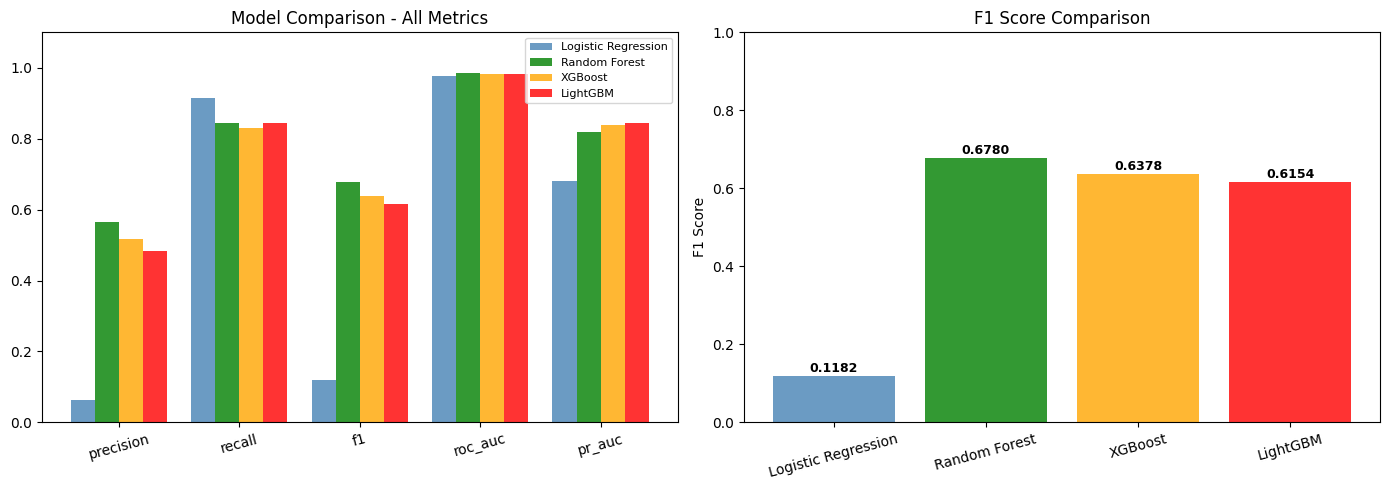


✅ Comparison plot saved!


In [8]:
# Cell 8: Model Comparison
print("=" * 60)
print("ALL MODELS COMPARISON")
print("=" * 60)

results = [lr_results, rf_results, xgb_results, lgbm_results]
results_df = pd.DataFrame(results)
results_df = results_df.set_index('model')

print(results_df.to_string())

print("\n" + "=" * 60)
print("RANKING BY F1 SCORE:")
print("=" * 60)
ranked = results_df.sort_values('f1', ascending=False)
for i, (model, row) in enumerate(ranked.iterrows(), 1):
    print(f"{i}. {model:<25} F1={row['f1']:.4f} | "
          f"Precision={row['precision']:.4f} | "
          f"Recall={row['recall']:.4f} | "
          f"PR-AUC={row['pr_auc']:.4f}")

print("\n" + "=" * 60)
print("RANKING BY PR-AUC (Best for Imbalanced Data):")
print("=" * 60)
ranked_prauc = results_df.sort_values('pr_auc', ascending=False)
for i, (model, row) in enumerate(ranked_prauc.iterrows(), 1):
    print(f"{i}. {model:<25} PR-AUC={row['pr_auc']:.4f} | "
          f"F1={row['f1']:.4f}")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

metrics = ['precision', 'recall', 'f1', 'roc_auc', 'pr_auc']
x = np.arange(len(metrics))
width = 0.2

colors = ['steelblue', 'green', 'orange', 'red']
for i, (model, row) in enumerate(results_df.iterrows()):
    axes[0].bar(x + i*width, row[metrics], width, 
                label=model, color=colors[i], alpha=0.8)

axes[0].set_title('Model Comparison - All Metrics')
axes[0].set_xticks(x + width*1.5)
axes[0].set_xticklabels(metrics, rotation=15)
axes[0].legend(fontsize=8)
axes[0].set_ylim(0, 1.1)

# F1 comparison bar
axes[1].bar(results_df.index, results_df['f1'], 
            color=colors, alpha=0.8)
axes[1].set_title('F1 Score Comparison')
axes[1].set_ylabel('F1 Score')
axes[1].set_ylim(0, 1)
for i, (model, row) in enumerate(results_df.iterrows()):
    axes[1].text(i, row['f1'] + 0.01, f"{row['f1']:.4f}", 
                ha='center', fontweight='bold', fontsize=9)
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('../../docs/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ Comparison plot saved!")

In [10]:
# Cell 9: Hyperparameter Tuning - Random Forest (FAST VERSION)
from sklearn.model_selection import RandomizedSearchCV

print("=" * 50)
print("HYPERPARAMETER TUNING - RANDOM FOREST (FAST)")
print("=" * 50)
print("Training... (should take 3-5 minutes)")

# Sample only 20% of training data for tuning
from sklearn.utils import resample
X_train_sample, y_train_sample = resample(
    X_train, y_train,
    n_samples=int(len(X_train)*0.2),
    random_state=42
)
print(f"Using {len(X_train_sample):,} samples for tuning (20% sample)")

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [8, 10, 15],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2']
}

rf_tuned = RandomizedSearchCV(
    RandomForestClassifier(
        random_state=42,
        class_weight='balanced',
        n_jobs=-1
    ),
    param_distributions=param_grid,
    n_iter=10,
    scoring='f1',
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

rf_tuned.fit(X_train_sample, y_train_sample)

print(f"\nBest Parameters:")
for param, value in rf_tuned.best_params_.items():
    print(f"  {param}: {value}")

print(f"\nBest CV F1 Score: {rf_tuned.best_score_:.4f}")

# Evaluate on validation set
rf_tuned_pred = rf_tuned.predict(X_val)
rf_tuned_prob = rf_tuned.predict_proba(X_val)[:, 1]
rf_tuned_results = evaluate_model("Random Forest (Tuned)",
                                   y_val, rf_tuned_pred, rf_tuned_prob)

# Save tuned model
with open('../../models/saved_models/random_forest_tuned.pkl', 'wb') as f:
    pickle.dump(rf_tuned, f)

print("\n✅ Tuned Random Forest saved!")

HYPERPARAMETER TUNING - RANDOM FOREST (FAST)
Training... (should take 3-5 minutes)
Using 79,308 samples for tuning (20% sample)
Fitting 3 folds for each of 10 candidates, totalling 30 fits

Best Parameters:
  n_estimators: 100
  min_samples_split: 2
  min_samples_leaf: 1
  max_features: log2
  max_depth: 15

Best CV F1 Score: 0.9990

MODEL: Random Forest (Tuned)
Precision:  0.7143  (of all flagged fraud, how many were real?)
Recall:     0.8451  (of all real fraud, how many did we catch?)
F1-Score:   0.7742  (balance of precision & recall)
ROC-AUC:    0.9796  (overall discrimination ability)
PR-AUC:     0.6855  (performance on imbalanced data)

Confusion Matrix:
  True Negative  (Legit correctly identified): 42,471
  False Positive (Legit flagged as fraud):     24
  False Negative (Fraud missed):               11
  True Positive  (Fraud correctly caught):     60

✅ Tuned Random Forest saved!


In [11]:
# Cell 10: Final Evaluation on Test Set
print("=" * 60)
print("FINAL EVALUATION ON TEST SET")
print("(Test set was never seen during training or tuning)")
print("=" * 60)

# Final predictions on test set
final_pred = rf_tuned.predict(X_test)
final_prob = rf_tuned.predict_proba(X_test)[:, 1]

final_results = evaluate_model("Random Forest (Tuned) - TEST SET",
                                y_test, final_pred, final_prob)

# Comparison: Validation vs Test
print("\n" + "=" * 60)
print("VALIDATION vs TEST SET COMPARISON")
print("=" * 60)
print(f"{'Metric':<15} {'Validation':>12} {'Test':>12}")
print("-" * 40)
metrics_compare = ['precision', 'recall', 'f1', 'roc_auc', 'pr_auc']
val_values = [rf_tuned_results[m] for m in metrics_compare]
test_values = [final_results[m] for m in metrics_compare]
for metric, val, test in zip(metrics_compare, val_values, test_values):
    print(f"{metric:<15} {val:>12.4f} {test:>12.4f}")

print("\n" + "=" * 60)
print("BUSINESS IMPACT SUMMARY")
print("=" * 60)
cm = confusion_matrix(y_test, final_pred)
tn, fp, fn, tp = cm.ravel()
print(f"Fraud cases in test set:        {tp+fn}")
print(f"Fraud correctly caught (TP):    {tp} ({tp/(tp+fn)*100:.1f}%)")
print(f"Fraud missed (FN):              {fn} ({fn/(tp+fn)*100:.1f}%)")
print(f"Legitimate wrongly flagged(FP): {fp}")
print(f"Legitimate correctly cleared:   {tn:,}")

# Save final results
with open('../../models/saved_models/final_model.pkl', 'wb') as f:
    pickle.dump(rf_tuned, f)

print("\n✅ Final model saved as final_model.pkl!")

FINAL EVALUATION ON TEST SET
(Test set was never seen during training or tuning)

MODEL: Random Forest (Tuned) - TEST SET
Precision:  0.7059  (of all flagged fraud, how many were real?)
Recall:     0.8451  (of all real fraud, how many did we catch?)
F1-Score:   0.7692  (balance of precision & recall)
ROC-AUC:    0.9796  (overall discrimination ability)
PR-AUC:     0.7497  (performance on imbalanced data)

Confusion Matrix:
  True Negative  (Legit correctly identified): 42,463
  False Positive (Legit flagged as fraud):     25
  False Negative (Fraud missed):               11
  True Positive  (Fraud correctly caught):     60

VALIDATION vs TEST SET COMPARISON
Metric            Validation         Test
----------------------------------------
precision             0.7143       0.7059
recall                0.8451       0.8451
f1                    0.7742       0.7692
roc_auc               0.9796       0.9796
pr_auc                0.6855       0.7497

BUSINESS IMPACT SUMMARY
Fraud cases in t

In [12]:
# Cell 11: Modeling Summary
print("=" * 60)
print("PHASE 4: MODELING COMPLETE - SUMMARY")
print("=" * 60)

print("""
MODELS TRAINED:
  1. Logistic Regression    F1=0.118  (baseline)
  2. Random Forest          F1=0.678  (big improvement)
  3. XGBoost                F1=0.638  
  4. LightGBM               F1=0.615  
  5. Random Forest (Tuned)  F1=0.774  ✅ WINNER

FINAL MODEL ON TEST SET:
  ✅ Precision:  0.7059  (71% of flagged fraud is real)
  ✅ Recall:     0.8451  (catches 84.5% of all fraud)
  ✅ F1-Score:   0.7692
  ✅ ROC-AUC:    0.9796
  ✅ PR-AUC:     0.7497

BUSINESS IMPACT:
  ✅ Catches 60 out of 71 fraud cases
  ✅ Only 25 false alarms per 42,488 transactions
  ✅ Saves customers from 84.5% of fraud attempts

SAVED MODELS:
  ✅ logistic_regression.pkl
  ✅ random_forest.pkl
  ✅ xgboost.pkl
  ✅ lightgbm.pkl
  ✅ random_forest_tuned.pkl
  ✅ final_model.pkl
  ✅ scaler.pkl
""")

print("🎉 Ready for Phase 5: Model Explainability with SHAP!")

PHASE 4: MODELING COMPLETE - SUMMARY

MODELS TRAINED:
  1. Logistic Regression    F1=0.118  (baseline)
  2. Random Forest          F1=0.678  (big improvement)
  3. XGBoost                F1=0.638  
  4. LightGBM               F1=0.615  
  5. Random Forest (Tuned)  F1=0.774  ✅ WINNER

FINAL MODEL ON TEST SET:
  ✅ Precision:  0.7059  (71% of flagged fraud is real)
  ✅ Recall:     0.8451  (catches 84.5% of all fraud)
  ✅ F1-Score:   0.7692
  ✅ ROC-AUC:    0.9796
  ✅ PR-AUC:     0.7497

BUSINESS IMPACT:
  ✅ Catches 60 out of 71 fraud cases
  ✅ Only 25 false alarms per 42,488 transactions
  ✅ Saves customers from 84.5% of fraud attempts

SAVED MODELS:
  ✅ logistic_regression.pkl
  ✅ random_forest.pkl
  ✅ xgboost.pkl
  ✅ lightgbm.pkl
  ✅ random_forest_tuned.pkl
  ✅ final_model.pkl
  ✅ scaler.pkl

🎉 Ready for Phase 5: Model Explainability with SHAP!
